Análisis exploratorio inicial de la base, caracterizando sus atributos y describiendo su comportamiento, distribución de variables, presencia de outliers, valores nulos y demás particularidades que crea de relevancia para el análisis.

long: Longitud geográfica (X coordinate) donde se encuentra el árbol.
lat: Latitud geográfica (Y coordinate) donde se encuentra el árbol.
nro_registro: Número de registro único del árbol en el sistema.
tipo_activ 	string 	Tipo de actividad o clasificación del árbol (e.g., 'Lineal').
comuna 	string 	Número de la comuna donde se encuentra el árbol.
manzana 	string 	Identificador de la manzana donde se encuentra el árbol.
calle_nombre 	string 	Nombre de la calle donde se encuentra ubicado el árbol.
calle_altura 	string 	Altura de la calle donde se encuentra el árbol.
calle_chapa 	string 	Número de chapa de la calle más cercano al árbol.
direccion_normalizada 	string 	Dirección normalizada para la ubicación del árbol (e.g., 'ESMERALDA 1120').
ubicacion 	string 	Información adicional sobre la ubicación del árbol (e.g., 'Exacta').
nombre_cientifico 	string 	Nombre científico de la especie del árbol.
ancho_acera 	string 	Ancho de la acera donde está ubicado el árbol, en metros.
estado_plantera 	string 	Estado de la plantación (e.g., 'Ocupada').
ubicacion_plantera 	string 	Condición de la ubicación de la plantación (e.g., 'Regular').
nivel_plantera 	string 	Nivel de la plantación respecto al suelo (e.g., 'A nivel, Elevada').
diametro_altura_pecho 	string 	Diámetro del árbol a la altura del pecho, en centímetros.
altura_arbol 	string 	Altura del árbol en metros.

long: Cuantitativa continua
lat: cuantitativa continua
nro_registro: Cualitativo nominal
tipo_activ: Cualitativo nominal
comuna: Cualitativo nominal
manzana: Cualitativo nominal
calle_nombre: Cualitativo nominal
calle_altura: Cuantitativo discreto
calle_chapa: cuantitativo discreto
direccion_normalizada: Cualitativo nominal
ubicacion: Cualitativo nominal
nombre_cientifico: Cualitativo nominal
ancho_acera: Cuantitativo  continuo
estado_plantera: Cualitativo nominal
ubicacion_plantera: Cualitativo nominal
nivel_plantera: Cualitativo nominal
diametro_altura_pecho: Cuantitativo continuo
altura_arbol: Cuantitativo continuo

In [2]:

from wget import download
from os import path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#abrimos el archivo de base de datos

dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")

dataset.info()
#dataset.head()
#dataset.describe()
dataset["comuna"].value_counts().sort_index()

/tmp/ipykernel_4620/1775283912.py:10: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

comuna
1     12723
2      7115
3     13320
4     32346
5     15224
6     15591
7     25608
8     21978
9     36405
10    33421
11    37340
12    38818
13    28287
14    22417
15    29587
Name: count, dtype: int64

LIMPIEZA

tipo_activ: Pasamos todo a minuculas y quitamos los espacios en blanco de la palabra Lineal 
// cuando saber si usamos 0 y 1 para una variable? se podria usar aca?
que hacemos con calle?

manzana: Reconoce el tipo como string y signos, simbolos, etc.
// que hacemos con los nulos?? y las letras NO habia que borrarlas todavia, que hacemos con estas?
capaz pueden ser manzanas repetidas(revisarlo con lat y long)

calle_altura: Busco si no hay valores decimales, al no encontrar paso los datos a int64 q acepta nulos? o reemplazo los nulos con algo, por ej con 0?
//que hacemos con los nulos aca tmb?

calle_chapa: aca pasa lo mismo que con la var anterior

direccion_normalizada: pasamos todo a minuscula y sacamos los espacios en blanco, comas y simbolos
//ver que hacer con los datos, separamos calle y altura en columnas distintas?

ubicacion: pasamos todo a minusculas. 
//tenemos que cambiar todo lo que no sea exacta por no exacta? o que hacemos?

nombre_cientifico: pasamos todo a minuscula, nada mas para limpiar

estado_plantera: paso a minusculas y borro las palabras que estan demas.
//que hacemos con las que tienen dos cosas? hacemos dos columnas? una para saber si esta ocupada y otra para saber si esta cerrada

ubicacion_plantera: paso a minusculas, agrego las letras que faltan
//que hacemos con las que tieen mas de una cosa?

nivel_plantera: paso a minusculas, elimino espacios y agrupo valores como EL,elevadas,elevado,... por elevada. cambio los strings "nan" y "obs" por NaN de pandas
//que hacemos con ochava???

diametro_altura_pecho: no modificamos nada. todos los que no son enteros son NaN
//habria que cambiarlo? (como para eliminar el .0 que es innecesario si son todos enteros o nulos)

altura_arbol: lo mismo que diametro_altura_pecho

In [3]:
copiaDataset= dataset
copiaDataset["tipo_activ"] = copiaDataset["tipo_activ"].str.strip().str.lower()
#copiaDataset["tipo_activ"].value_counts()

copiaDataset["manzana"] = copiaDataset["manzana"].astype(str).str.strip().str.lower()
copiaDataset["manzana"] = copiaDataset["manzana"].str.replace(r'[^a-z0-9]', '',  regex=True)
copiaDataset["manzana"].value_counts()

copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].astype(str).str.strip().str.lower()
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].str.replace(r'[^a-z ]', '',  regex=True)
#copiaDataset["calle_nombre"].value_counts()

copiaDataset["calle_altura"] = pd.to_numeric(copiaDataset["calle_altura"], errors='coerce')#conierto la col en numerica, todo en float y si no en NaN
(copiaDataset["calle_altura"] % 1 != 0).any()#veo si hay valores decimales
#copiaDataset['calle_altura'] = copiaDataset['calle_altura'].astype(float).astype('Int64') 
copiaDataset["calle_altura"] = (copiaDataset["calle_altura"].fillna(0).astype(float).astype(int))
#copiaDataset["calle_altura"].value_counts()

copiaDataset["direccion_normalizada"] = (copiaDataset["direccion_normalizada"].astype(str).str.strip().str.lower())
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r',', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'[^a-z0-9áéíóúñ ]', '', regex=True)
# Extraer altura (último número de la cadena)
copiaDataset["altura"] = copiaDataset["direccion_normalizada"].str.extract(r'(\d+)$')
# Quitar la altura de la dirección para quedarte con el nombre limpio
copiaDataset["calle"] = copiaDataset["direccion_normalizada"].str.replace(r'\s*\d+\s*$', '', regex=True)
#copiaDataset["direccion_normalizada"].value_counts()
#copiaDataset[['direccion_normalizada', 'calle', 'altura']].head(10)

copiaDataset["ubicacion"] = copiaDataset["ubicacion"].astype(str).str.strip().str.lower()
#copiaDataset["ubicacion"].value_counts()

copiaDataset["nombre_cientifico"] = copiaDataset["nombre_cientifico"].astype(str).str.strip().str.lower()
#copiaDataset["nombre_cientifico"].value_counts()

copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].astype(str).str.strip().str.lower()
#borro la palabra cantero
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('cantero ', '', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('ocupado', 'ocupada', regex=False)

copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["estado_plantera"].value_counts()

copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].astype(str).str.strip().str.lower()
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["elevadas","eleveda","el","elevado"],"elevada")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["bn","bajo bivel","baja nivel","reducida"],"bajo nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["an","regular"],"a nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["nan","obs: no tiene plantera definida"],np.nan)
#copiaDataset["nivel_plantera"].value_counts()
#copiaDataset["nivel_plantera"].isna().sum()

# Filtrar solo los valores que no son enteros y mostrar solo la columna
no_enteros = copiaDataset.loc[copiaDataset["diametro_altura_pecho"] % 1 != 0, "diametro_altura_pecho"]
#print(no_enteros)
#copiaDataset["diametro_altura_pecho"].isna().sum()

#print(copiaDataset.loc[copiaDataset["altura_arbol"] % 1 != 0, "altura_arbol"])
#copiaDataset["altura_arbol"].isna().sum()


ANALISIS UNIVARIADO

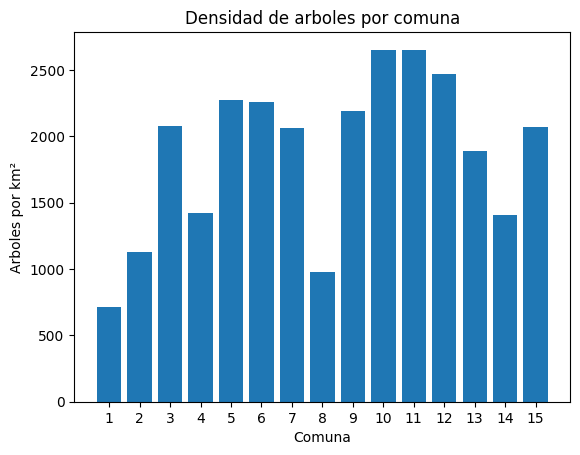

In [4]:
#Las comunas del norte de la Ciudad de Buenos Aires (como la 12, 13 y 14) 
# presentan mayor densidad de árboles por superficie urbana que las comunas del sur (4, 8 y 9).

superficies = { #en km²
    1: 17.9,  2: 6.3,  3: 6.4,  4: 22.7,  5: 6.7,
    6: 6.9,  7: 12.4, 8: 22.5, 9: 16.6, 10: 12.6,
    11: 14.1, 12: 15.7, 13: 15.0, 14: 15.9, 15: 14.3
}

datasetH1 = copiaDataset[["comuna"]].copy()

# 1️⃣ Contar cantidad de árboles por comuna
arboles_por_comuna = datasetH1.groupby("comuna").size().reset_index(name="cantidad_arboles")

# 2️⃣ Agregar la superficie de cada comuna
arboles_por_comuna["superficie"] = arboles_por_comuna["comuna"].map(superficies)

# 3️⃣ Calcular densidad de árboles por km²
arboles_por_comuna["densidad_arboles"] = arboles_por_comuna["cantidad_arboles"] / arboles_por_comuna["superficie"]

# graficamos el histograma
plt.bar(arboles_por_comuna["comuna"], arboles_por_comuna["densidad_arboles"])
plt.xticks(range(1,16))  
plt.xlabel("Comuna")
plt.ylabel("Arboles por km²")
plt.title("Densidad de arboles por comuna")
plt.show()


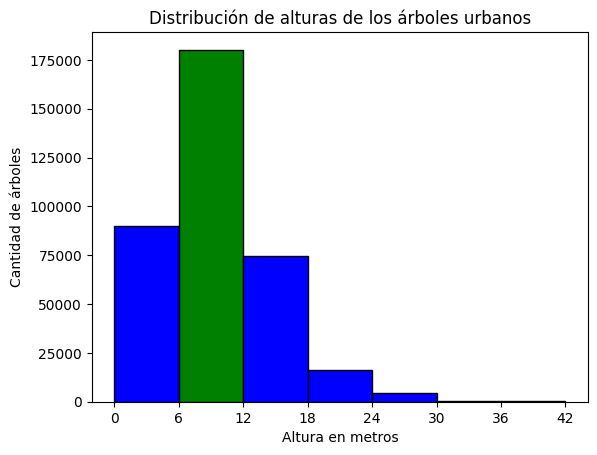

In [5]:
#La mayoría de los árboles tienen una altura media entre 6 y 12 metros, 
# correspondiente a especies medianas.

n, bins, barras = plt.hist(copiaDataset["altura_arbol"], bins=[0, 6, 12, 18, 24, 30, 36, 42], edgecolor="black")

# Cambiar el color de la barra correspondiente al intervalo 6–12
for i in range(len(barras)):
    if bins[i] == 6:  # este es el inicio del intervalo 6–12
        barras[i].set_facecolor("green") 
    else:
        barras[i].set_facecolor("blue") 

# Etiquetas en el eje X 
plt.xticks([0, 6, 12, 18, 24, 30, 36, 42])
plt.xlabel("Altura en metros")
plt.ylabel("Cantidad de árboles")
plt.title("Distribución de alturas de los árboles urbanos")
plt.show()

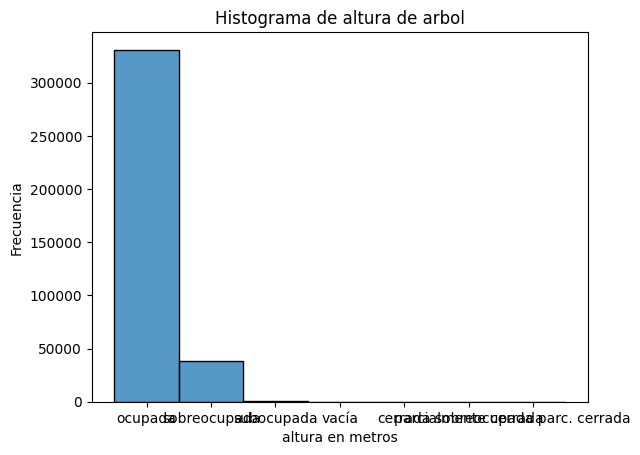

In [6]:
#Más del 90% de las planteras del arbolado público están ocupadas por árboles activos.

#ACA QUE HACEMOS?? USAMOS SOLAMENTE LAS OCUPADAS? Y CON SOBREOCUPADAS?
sns.histplot(dataset["estado_plantera"], bins=15, kde=False)
plt.title("Histograma de altura de arbol")
plt.xlabel("altura en metros")
plt.ylabel("Frecuencia")
plt.show()

Existe una relación positiva significativa entre la altura del arbol y su cercania al Rio de la Plata.

Formas de plantear la distancia: 
1. tomamos un punto de referencia del rio (ej a la altura de caba)
2. tomamos diferentes puntos a lo largo del rio (da valores mas reales)

Elegimos la opcion 2.
Para elegir estos puntos tenemos en cuenta las comunas que limitan al rio (1,2,4,13 y 14) y elegimos un punto especifico de cada una de ellas.
Comuna 1. Puerto Madero (34°36'25.1"S 58°20'44.9"W)
Comuna 2. Recoleta (34°34'30.2"S 58°23'15.0"W)
Comuna 13. Belgrano (34°32'51.6"S 58°25'50.0"W)
Comuna 14. Palermo (34°33'23.9"S 58°24'37.0"W)

In [13]:
from shapely.geometry import Point,LineString
import geopandas as gpd

coords = [
    (-34.36,-58.20), #Puerto Madero
    (-34.34,-58.23), #Recoleta
    (-34.32,58.25), #Belgrano
    (-34.33,-58.24), #Palermo
]

linea_rio = LineString(coords)
datasetH4 = copiaDataset[["altura_arbol","lat","long"]].copy()

datasetH4["distancia_rio"] = datasetH4.apply(lambda row: Point(row["long"], row["lat"]).distance(linea_rio),
    axis=1
)




/home/valentina-bulat/.local/lib/python3.13/site-packages/shapely/measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)
